# 1. IMPORTS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 2. Importación de datasets 

In [2]:
from pathlib import Path

base_dir = 'kdd_datasets - tratados'


def load_all_datasets(base_dir: str = 'kdd_datasets - tratados') -> dict[str, pd.DataFrame]:
    """Carga todos los CSV del directorio y devuelve un diccionario de DataFrames."""
    base_path = Path(base_dir)
    if not base_path.exists():
        raise FileNotFoundError(f'Directorio no encontrado: {base_path}')

    datasets = {
        csv_file.stem: pd.read_csv(csv_file)
        for csv_file in sorted(base_path.glob('*.csv'))
    }
    return datasets


datasets = load_all_datasets(base_dir)

# Asignar variables opcionales para uso directo
for name in [
    'condiciones_climaticas',
    'imagenes_metadata',
    'noticias_agricolas',
    'politicas_agricolas',
    'precios_mercado',
    'produccion_agricola',
    'produccion_ganadera',
    'reportes_plagas',
]:
    globals()[name] = datasets[name]

# Mostrar los tamaños de cada dataset
for name, df in datasets.items():
    print(f'{name}: {df.shape}')


condiciones_climaticas: (256, 13)
imagenes_metadata: (250, 15)
noticias_agricolas: (60, 9)
politicas_agricolas: (148, 13)
precios_mercado: (864, 9)
produccion_agricola: (1200, 11)
produccion_ganadera: (600, 9)
reportes_plagas: (100, 11)


In [3]:
datasets['condiciones_climaticas'].head()

,codigo_iso,pais,regiones_anio,regiones_dias_con_heladas,regiones_eventos_extremos,regiones_humedad_relativa_promedio,regiones_indice_aridez,regiones_meses_estres_hidrico,regiones_nombre,regiones_precipitacion_total,regiones_temperatura_maxima,regiones_temperatura_minima,regiones_temperatura_promedio
0,ARG,Argentina,2017,62,NaN,40,24.06,4,Cuyo,1074,22.5,"0,5",12.4
1,ARG,Argentina,2015,4,NaN,70,19.09,2,Cuyo,873,20.8,"0,9",12.7
2,ARG,Argentina,2019,111,NaN,64,16.19,1,Cuyo,880,29.9,"4,8",15.1
3,ARG,Argentina,2018,64,NaN,68,12.85,0,Cuyo,907,30.6,"6,6",19.6
4,ARG,Argentina,2016,93,NaN,83,29.64,0,Cuyo,1387,22.6,"7,2",13.0


In [4]:
datasets['imagenes_metadata'].head()

,imagen_id,pais,region,fecha,indice_ndvi_promedio,indice_ndvi_min,indice_ndvi_max,indice_evi,uso_suelo_predominante,humedad_suelo_estimada,cobertura_nubes,resolucion_metros,satelite,bandas_disponibles,calidad_imagen
0,SAT_FRA_202001_000,Francia,Región Principal,2020-01-15,0.391,0.259,0.432,0.432,bosque,0.378,0.074,30,MODIS,"RGB, NIR, SWIR",media
1,SAT_ARG_202001_001,Argentina,Noroeste,2020-01-31,0.488,0.390,0.601,0.555,mixto,0.480,0.055,30,Sentinel-2,"RGB, NIR, SWIR",baja
2,SAT_CHN_202003_002,China,Región Principal,2020-03-01,0.546,0.433,0.622,0.655,urbano,0.552,0.099,20,MODIS,"RGB, NIR, SWIR",baja
3,SAT_DEU_202003_003,Alemania,Región Principal,2020-03-12,0.601,0.446,0.655,0.744,urbano,0.644,0.209,60,Sentinel-2,"RGB, NIR, SWIR",media
4,SAT_FRA_202003_004,Francia,Región Principal,2020-03-22,0.639,0.518,0.753,0.792,mixto,0.441,0.249,10,Sentinel-2,"RGB, NIR, SWIR",baja


# 3. Análisis exploratorio por tipo de datos


### 3.1 ¿Cómo se relaciona el uso de fertilizantes con el rendimiento?

##### Primero, generamos un dataset con los datos a estudiar

In [5]:
fertilizante_rendimiento = datasets['produccion_agricola'][
    ['pais', 'region', 'cultivo', 'anio', 'fertilizantes_kg_ha', 'rendimiento_ton_ha']
].dropna()

fertilizante_rendimiento.head()

,pais,region,cultivo,anio,fertilizantes_kg_ha,rendimiento_ton_ha
0,Argentina,América del Sur,Soja,2011,105,2.22
1,Argentina,América del Sur,Maíz,2011,164,8.45
2,Argentina,América del Sur,Cebada,2011,105,2.77
3,Argentina,América del Sur,Té,2011,236,3.07
4,Argentina,América del Sur,Algodón,2011,276,1.18


##### Comprobamos que no haya nulos

In [6]:
fertilizante_rendimiento.isna().sum()

pais                   0
region                 0
cultivo                0
anio                   0
fertilizantes_kg_ha    0
rendimiento_ton_ha     0
dtype: int64

##### Al hacer el gráfico de correlación entre fertilizante y rendimiento se puede comprobar como no existe casi ninguna correlación entre ambos. Esto quiere decir que los cambios en las cantidades de fertilizantes usados no parecen tener ningún efecto en el crecimiento de los cultivos

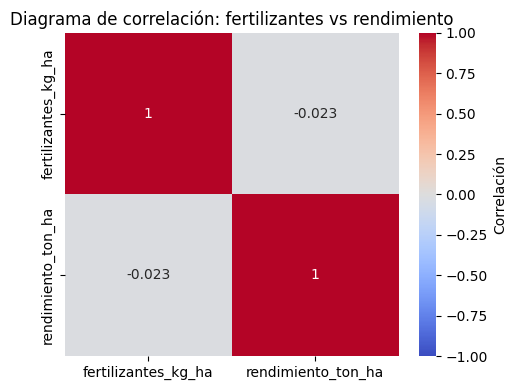

In [7]:
corr_matrix = fertilizante_rendimiento[['fertilizantes_kg_ha', 'rendimiento_ton_ha']].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Correlación'}
)
plt.title('Diagrama de correlación: fertilizantes vs rendimiento')
plt.tight_layout()
plt.show()

##### En el caso del scatterplot donde se muestra la relación previa teniendo en cuenta los distintos cultivos, se puede ver que el rendimiento de la caña de azucar excede por bastante al resto de cultivos, que parecen tener un rendimiento casi nulo. Esto podría ser porque el uso de fertilizantes si que ayuda y aporta al crecimiento de la caña, mientras que al resto no les mejora tanto y por eso la relación previa es baja.

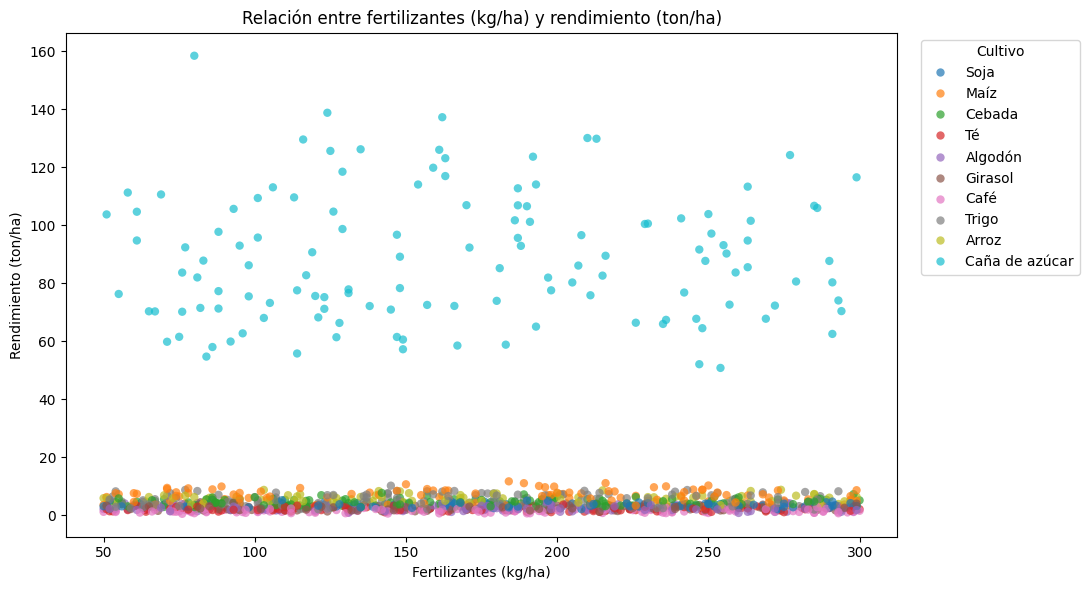

In [8]:
plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=fertilizante_rendimiento,
    x='fertilizantes_kg_ha',
    y='rendimiento_ton_ha',
    hue='cultivo',
    alpha=0.7,
    edgecolor='none'
)
plt.title('Relación entre fertilizantes (kg/ha) y rendimiento (ton/ha)')
plt.xlabel('Fertilizantes (kg/ha)')
plt.ylabel('Rendimiento (ton/ha)')
plt.legend(title='Cultivo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### Haciendo un análisis mas exhaustivo de la correlación que hay con cada cultivo, hemos visto que en realidad en el caso de la caña no hay un patrón claro con los estudios previos. Es decir, si bien su rendimiento es superior al resto de cultivos, su correlación con la cantidad de fertilizante y rendimiento es bastante baja por lo que no podemos afirmar que su "alto" rendimiento se deba a ello.

In [9]:
corr_por_cultivo_fertilizante = []
for cultivo, grupo in fertilizante_rendimiento.groupby('cultivo'):
    corr = grupo['fertilizantes_kg_ha'].corr(grupo['rendimiento_ton_ha'])
    corr_por_cultivo_fertilizante.append({'cultivo': cultivo, 'correlacion': corr, 'muestras': len(grupo)})

corr_por_cultivo_fertilizante = pd.DataFrame(corr_por_cultivo_fertilizante).sort_values('correlacion', ascending=False)
print(corr_por_cultivo_fertilizante)

          cultivo  correlacion  muestras
4          Cebada     0.119962       140
2            Café     0.085235       130
5         Girasol     0.051202       120
3  Caña de azúcar     0.016324       130
7            Soja     0.006739       110
8           Trigo    -0.002747       140
1           Arroz    -0.024686        90
9              Té    -0.037031       110
6            Maíz    -0.065162       110
0         Algodón    -0.092416       120


##### **Conclusión**: En este dataset, la cantidad de fertilizante aplicada no parece ser un buen predictor lineal del rendimiento. Aunque la caña de azúcar muestra rendimientos altos, su correlación con fertilizante sigue siendo baja, por lo que su rendimiento se debe a otros factores más que al fertilizante medido. La variación de rendimiento probablemente se explica mejor con variables adicionales o con análisis estratificado por cultivo, no con un simple fertilizantes_kg_ha vs rendimiento_ton_ha.”

### 3.2 ¿Existe correlación entre superficie cultivada y producción?

##### Preparación del dataset

In [10]:
superficie_produccion = datasets['produccion_agricola'][
    ['pais', 'region', 'cultivo', 'anio', 'superficie_hectareas', 'produccion_ton']
].dropna()

superficie_produccion.head()


,pais,region,cultivo,anio,superficie_hectareas,produccion_ton
0,Argentina,América del Sur,Soja,2011,4703643,10465461
1,Argentina,América del Sur,Maíz,2011,3371781,28485921
2,Argentina,América del Sur,Cebada,2011,1661577,4596917
3,Argentina,América del Sur,Té,2011,188518,577886
4,Argentina,América del Sur,Algodón,2011,1638327,1929756


##### Comprobación de nulos

In [11]:
superficie_produccion.isna().sum()

pais                    0
region                  0
cultivo                 0
anio                    0
superficie_hectareas    0
produccion_ton          0
dtype: int64

##### La correlación entre la superficie cultivada y la producción tienen una correlación media y positiva. En un primer vistazo se podría decir que a mayor superficie cultivada, mayor producción. Al ser correlación media puede que existan otros factores que afecten.

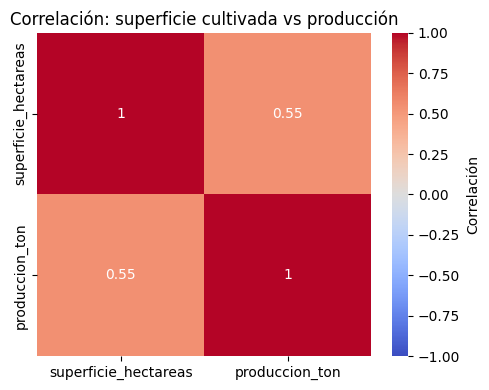

In [12]:
corr_matrix = superficie_produccion[['superficie_hectareas', 'produccion_ton']].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Correlación'}
)
plt.title('Correlación: superficie cultivada vs producción')
plt.tight_layout()
plt.show()

##### Al hacer un gráfico de correlación tomando en cuenta más variables hemos descubierto que el rendimiento está estrechamente correlacionado a la producción. Una vez resolvamos la cuestión propuesta estudiaremos este caso.

<Axes: >

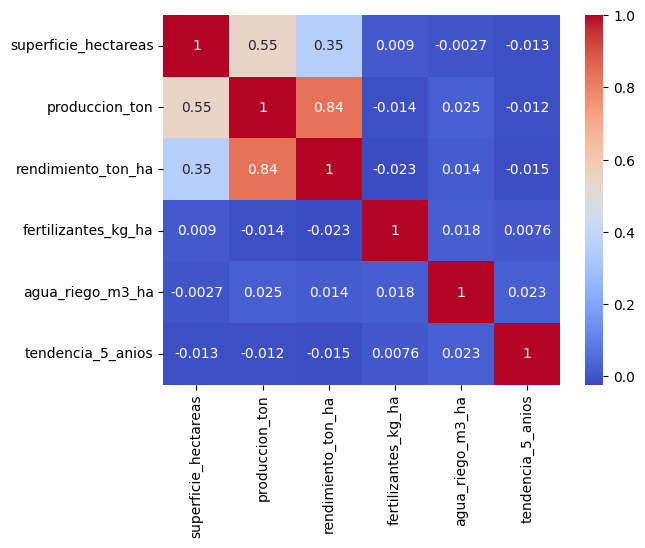

In [13]:
vars_estudio = [
    'superficie_hectareas',
    'produccion_ton',
    'rendimiento_ton_ha',
    'fertilizantes_kg_ha',
    'agua_riego_m3_ha',
    'tendencia_5_anios'
]
sub = datasets['produccion_agricola'][vars_estudio].dropna()
sns.heatmap(sub.corr(), annot=True, cmap='coolwarm')

##### El scatterplot confirma que a mayor hectáreas de cultivo, mayor es su producción. Nuevamente la caña de azucar sobresale del resto de cultivos en la gráfica, lo que ya nos puede ir indicando que es el cultivo que mejor rendimiento tiene.

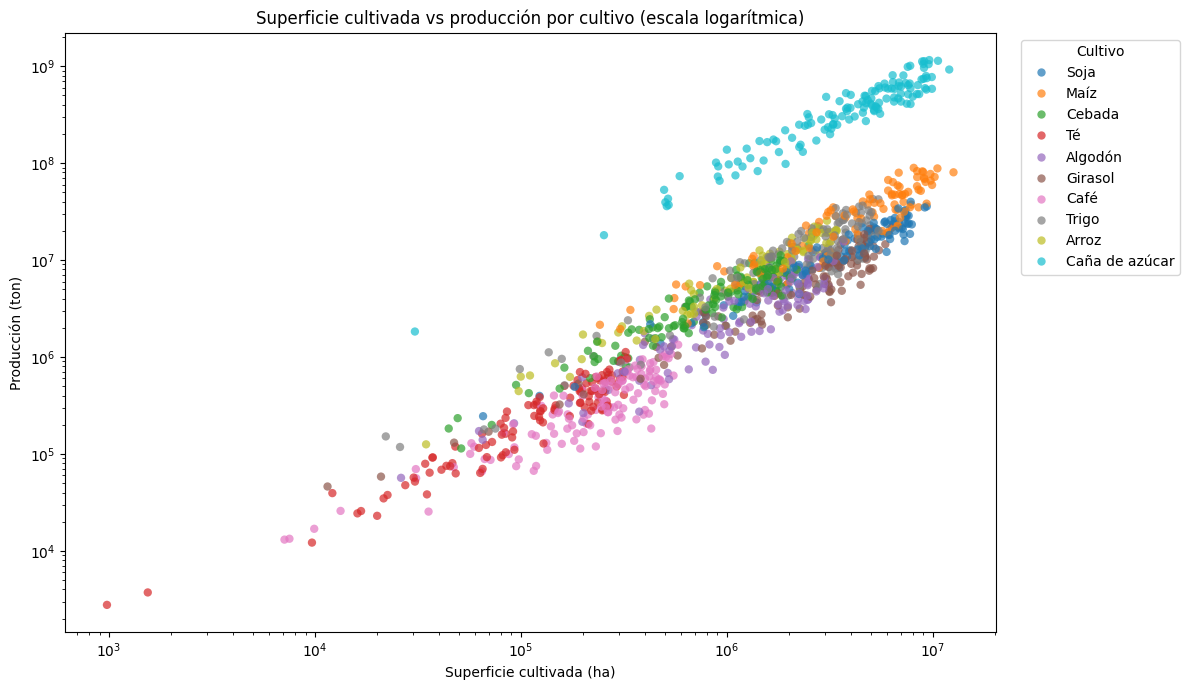

In [14]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=superficie_produccion,
    x='superficie_hectareas',
    y='produccion_ton',
    hue='cultivo',
    alpha=0.7,
    edgecolor='none'
)
plt.xscale('log')
plt.yscale('log')
plt.title('Superficie cultivada vs producción por cultivo (escala logarítmica)')
plt.xlabel('Superficie cultivada (ha)')
plt.ylabel('Producción (ton)')
plt.legend(title='Cultivo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### Al trazar una línea sobre el gráfico anterior podemos comprobar que la relación es consistente y se ajusta bastante a los datos. Se puede comprobar como la caña de azúcar sobresale, casi como un outlier, ya que produce mucho más que el resto.

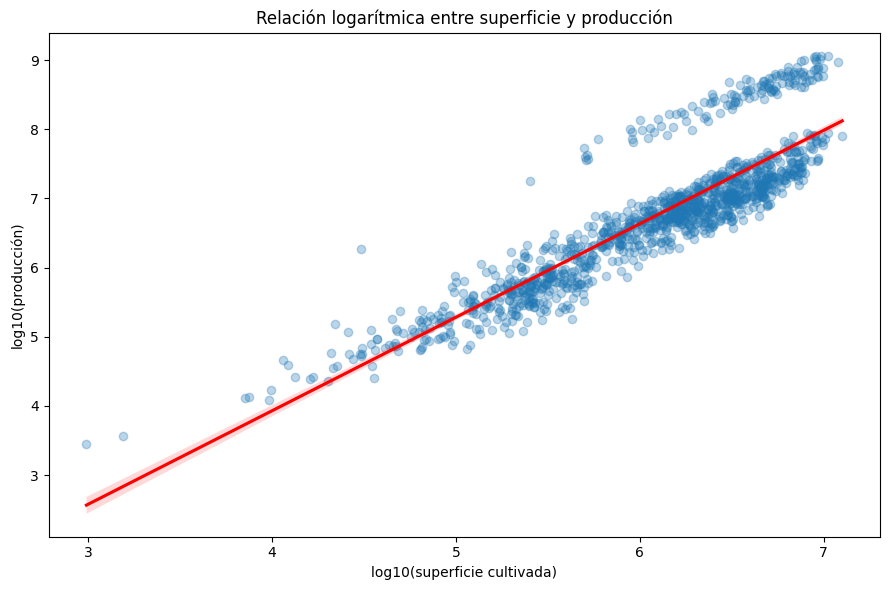

In [15]:
log_superficie = np.log10(superficie_produccion['superficie_hectareas'])
log_produccion = np.log10(superficie_produccion['produccion_ton'])

plt.figure(figsize=(9, 6))
sns.regplot(
    x=log_superficie,
    y=log_produccion,
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'}
)
plt.title('Relación logarítmica entre superficie y producción')
plt.xlabel('log10(superficie cultivada)')
plt.ylabel('log10(producción)')
plt.tight_layout()
plt.show()

##### Al estudiar también en este caso la correlación individual de cada cultivo, terminamos de asegurar que claramente la superficie afecta en gran medida a la producción de ese tipo de cultivo.

In [16]:
corr_por_cultivo_superficie = []
for cultivo, grupo in superficie_produccion.groupby('cultivo'):
    corr = grupo['superficie_hectareas'].corr(grupo['produccion_ton'])
    corr_por_cultivo_superficie.append({'cultivo': cultivo, 'correlacion': corr, 'muestras': len(grupo)})

corr_por_cultivo_superficie = pd.DataFrame(corr_por_cultivo_superficie).sort_values('correlacion', ascending=False)
print(corr_por_cultivo_superficie)

          cultivo  correlacion  muestras
1           Arroz     0.930776        90
7            Soja     0.926807       110
3  Caña de azúcar     0.897172       130
4          Cebada     0.880106       140
9              Té     0.879218       110
6            Maíz     0.875522       110
5         Girasol     0.872805       120
0         Algodón     0.849956       120
2            Café     0.788033       130
8           Trigo     0.784814       140


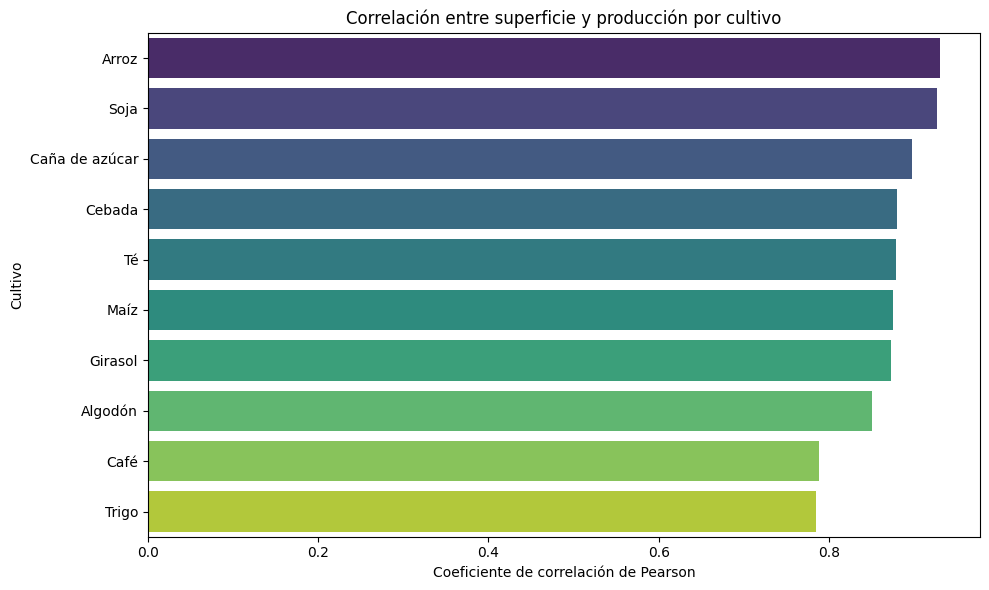

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=corr_por_cultivo_superficie,
    x='correlacion',
    y='cultivo',
    hue='cultivo',
    palette='viridis',
    dodge=False,
    legend=False
)
plt.title('Correlación entre superficie y producción por cultivo')
plt.xlabel('Coeficiente de correlación de Pearson')
plt.ylabel('Cultivo')
plt.tight_layout()
plt.show()

##### **Conclusión**: Se ha confirmado una correlación positiva en este caso, por lo que podemos asegurar que a mayor superficie cultivada, mayor es también la producción que obtenemos.

### 3.3 Tendencias de producción por país y cultivo

##### En esta sección se analizan las tendencias de producción total por país y por cultivo a lo largo del tiempo. Primero preparamos el dataset.

In [18]:
produccion = datasets['produccion_agricola'][
    ['pais', 'cultivo', 'anio', 'produccion_ton']
].dropna()

produccion_pais = (
    produccion[produccion['pais'].notnull()]
    .groupby(['anio', 'pais'])['produccion_ton']
    .sum()
    .reset_index()
)
produccion_cultivo = (
    produccion[produccion['cultivo'].notnull()]
    .groupby(['anio', 'cultivo'])['produccion_ton']
    .sum()
    .reset_index()
)

##### Haciendo un primer gráfico de tendencia, podemos comprobar como paises como China o Brasil parecen tener una capacidad de producción mucho mayor que el resto de paises. También se puede visualizar una alta volatilidad del mercado con picos pronunciados. Otros paises como Argentina tienen una producción más baja pero estable. En el año 2018 se puede observar una gran bajada general del mercado con picos mínimos pronunciados, mientras que en el 2019 se produce una gran crecida de la producción. Esto podría deberse a cambios climáticos, de demanda general en el mercado, etc.

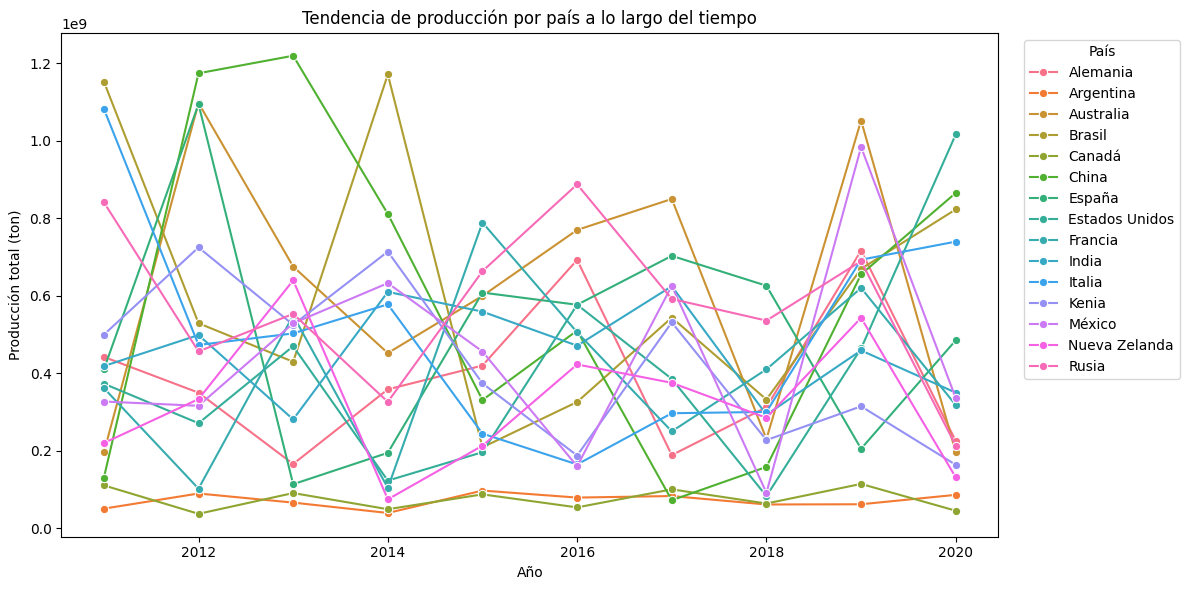

In [19]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=produccion_pais,
    x='anio',
    y='produccion_ton',
    hue='pais',
    marker='o'
)
plt.title('Tendencia de producción por país a lo largo del tiempo')
plt.xlabel('Año')
plt.ylabel('Producción total (ton)')
plt.legend(title='País', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### Escogemos unos paises concretos para obtener un gráfico más limpio. Podemos ver que con los seleccionados en este caso en concreto en el último tramo estudiado están al alza pero las conclusiones en este caso son las mismas, mucha volatilidad de mercado.

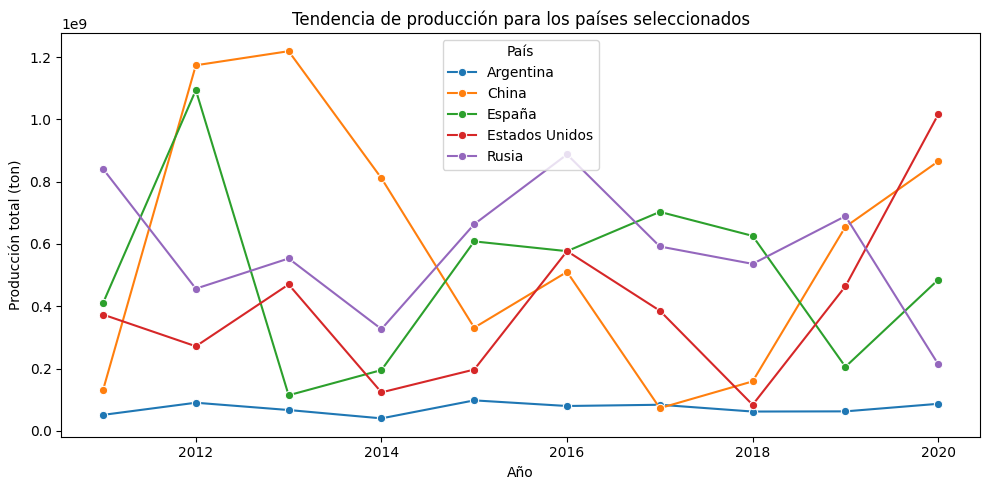

In [20]:
paises_seleccionados = ['China', 'Estados Unidos', 'Rusia', 'Argentina', 'España']
produccion_pais_filtrado = produccion_pais[produccion_pais['pais'].isin(paises_seleccionados)]

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=produccion_pais_filtrado,
    x='anio',
    y='produccion_ton',
    hue='pais',
    marker='o'
)
plt.title('Tendencia de producción para los países seleccionados')
plt.xlabel('Año')
plt.ylabel('Producción total (ton)')
plt.legend(title='País')
plt.tight_layout()
plt.show()

##### En la tendencia de producción por cultivo, como hemos repetido en varias ocasiones, se observa que la caña de azucar es el cultivo con mayor productividad de todos. El gráfico se encuentra sesgado ya que 1 solo cultivo ocupa la mayoría de la producción del mercado. El resto de cultivos son más estables aunque mucho más reducidos en cantidad. Nuevamente, se pueden observar picos en los años 2018-2019 que podrían deberse a factores climáticos, cambios en demanda o políticas agrarias.

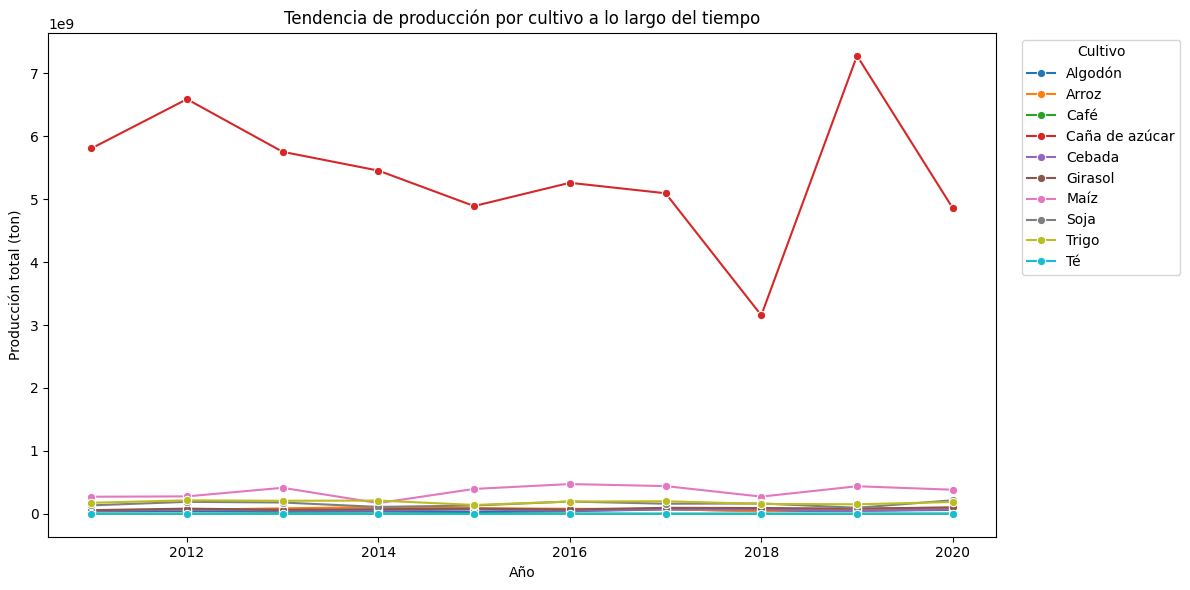

In [21]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=produccion_cultivo,
    x='anio',
    y='produccion_ton',
    hue='cultivo',
    marker='o'
)
plt.title('Tendencia de producción por cultivo a lo largo del tiempo')
plt.xlabel('Año')
plt.ylabel('Producción total (ton)')
plt.legend(title='Cultivo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### **Conclusion**: Los datos muestran una producción inestable, con caidas y subidas bruscas de la productividad. Algunos paises tienen un nivel de producción muy alto en años concretos, mientras que otros se mantienen más bajos y estables. Los factores externos tales como los climaticos, políticos o cambios en demanda pueden estar afectando éstas medidas, se necesita realizar un análisis de series temporales para poder sacar conclusiones más acertadas.

### 3.4 Detección de anomalías en series temporales

##### En esta sección usamos un método clásico de detección de anomalías: z-score simple sobre la producción total de cada serie. Esto es el método “ya existente” del análisis estadístico básico.

In [22]:
produccion = datasets['produccion_agricola'][
    ['anio', 'pais', 'cultivo', 'produccion_ton']
].dropna()

produccion_pais = (
    produccion.groupby(['anio', 'pais'])['produccion_ton']
    .sum()
    .reset_index()
    .sort_values(['pais', 'anio'])
)
produccion_cultivo = (
    produccion.groupby(['anio', 'cultivo'])['produccion_ton']
    .sum()
    .reset_index()
    .sort_values(['cultivo', 'anio'])
)


def add_zscore_anomaly(df, group_col, threshold=1.5):
    frames = []
    for _, group in df.groupby(group_col):
        g = group.copy()
        z = (g['produccion_ton'] - g['produccion_ton'].mean()) / g['produccion_ton'].std(ddof=0)
        g['z_score'] = z
        g['anomaly'] = z.abs() > threshold
        frames.append(g)
    return pd.concat(frames, ignore_index=True)

produccion_pais = add_zscore_anomaly(produccion_pais, 'pais')
produccion_cultivo = add_zscore_anomaly(produccion_cultivo, 'cultivo')

print('Anomalías detectadas por país:')
print(produccion_pais[produccion_pais['anomaly']].sort_values(['pais', 'anio']).head(10))
print('\nAnomalías detectadas por cultivo:')
print(produccion_cultivo[produccion_cultivo['anomaly']].sort_values(['cultivo', 'anio']).head(10))

Anomalías detectadas por país:
    anio            pais  produccion_ton   z_score  anomaly
5   2016        Alemania       692610614  1.685645     True
8   2019        Alemania       716530243  1.817782     True
13  2014       Argentina        39988861 -1.824109     True
21  2012       Australia      1097272038  1.511526     True
30  2011          Brasil      1152265497  1.672355     True
33  2014          Brasil      1170831134  1.730543     True
52  2013           China      1219148006  1.564035     True
61  2012          España      1094119337  2.141889     True
79  2020  Estados Unidos      1016150113  2.421956     True
84  2015         Francia       788984158  1.849147     True

Anomalías detectadas por cultivo:
    anio         cultivo  produccion_ton   z_score  anomaly
6   2017         Algodón        72613141  2.118343     True
13  2014           Arroz       110812706  1.574192     True
17  2018           Arroz        42783154 -1.999642     True
29  2020            Café         6

##### Este método calcula el z-score de cada año dentro de cada país o cultivo, y marca como anomalía aquellos valores de producción que están muy lejos de la media histórica de su serie.

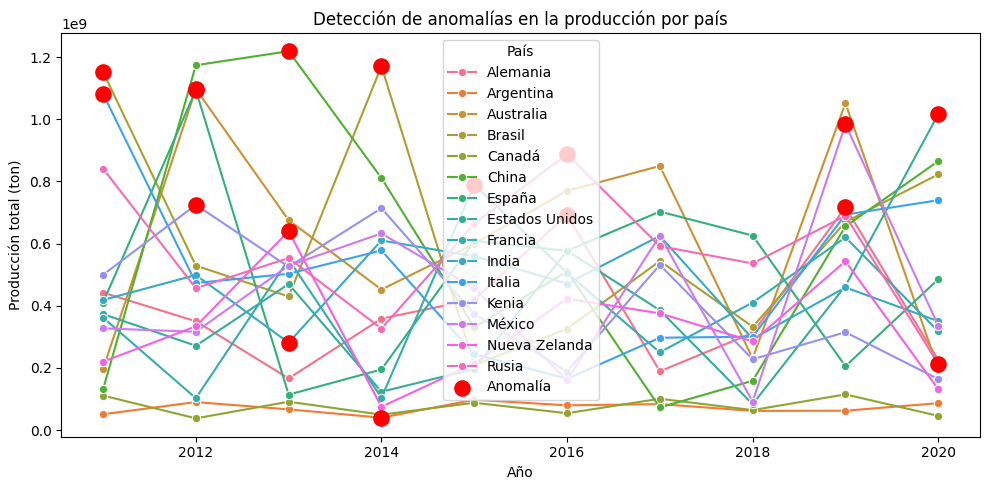

Años anómalos detectados:
               pais  anio  produccion_ton   z_score
5          Alemania  2016       692610614  1.685645
8          Alemania  2019       716530243  1.817782
13        Argentina  2014        39988861 -1.824109
21        Australia  2012      1097272038  1.511526
30           Brasil  2011      1152265497  1.672355
33           Brasil  2014      1170831134  1.730543
52            China  2013      1219148006  1.564035
61           España  2012      1094119337  2.141889
79   Estados Unidos  2020      1016150113  2.421956
84          Francia  2015       788984158  1.849147
92            India  2013       281247799 -1.513210
100          Italia  2011      1082067041  2.173972
111           Kenia  2012       724861518  1.534400
128          México  2019       983728502  2.171425
132   Nueva Zelanda  2013       639910930  1.874416
145           Rusia  2016       887521163  1.561600
149           Rusia  2020       213876958 -1.815654


In [23]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=produccion_pais,
    x='anio',
    y='produccion_ton',
    hue='pais',
    marker='o'
)

anomalies = produccion_pais[produccion_pais['anomaly']]
plt.scatter(
    anomalies['anio'],
    anomalies['produccion_ton'],
    color='red',
    s=120,
    label='Anomalía',
    zorder=5
)
plt.title('Detección de anomalías en la producción por país')
plt.xlabel('Año')
plt.ylabel('Producción total (ton)')
plt.legend(title='País')
plt.tight_layout()
plt.show()

print('Años anómalos detectados:')
print(anomalies[['pais', 'anio', 'produccion_ton', 'z_score']].sort_values(['pais', 'anio']))

##### El mismo criterio se aplica a los cultivos más importantes para detectar años con producción inusualmente alta o baja.

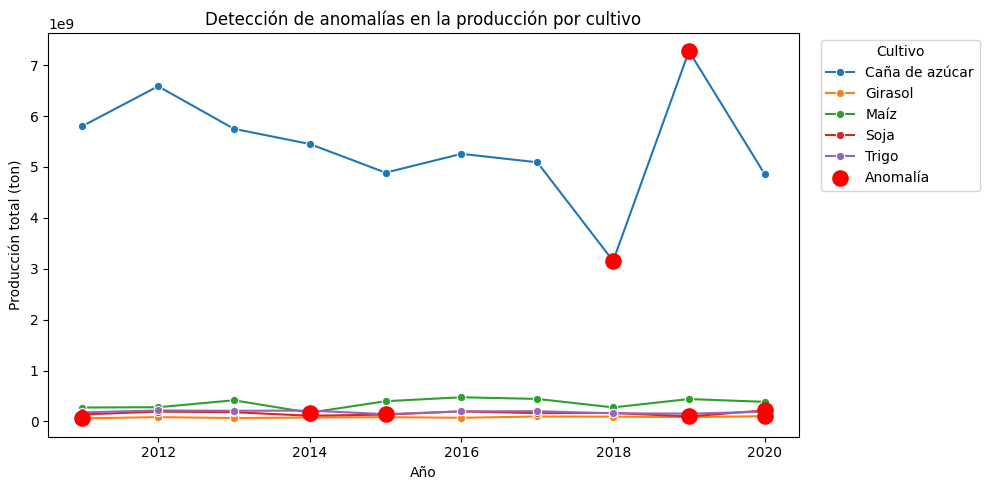

Años anómalos detectados para los cultivos top:
           cultivo  anio  produccion_ton   z_score
37  Caña de azúcar  2018      3154126781 -2.159338
38  Caña de azúcar  2019      7274705042  1.783179
50         Girasol  2011        60561272 -1.689457
59         Girasol  2020       103657218  1.604520
63            Maíz  2014       172703191 -1.956376
78            Soja  2019        98403573 -1.669801
79            Soja  2020       217657295  1.556136
84           Trigo  2015       143068861 -1.724713


In [24]:
cultivos_top = (
    produccion.groupby('cultivo')['produccion_ton']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)
cultivo_filtrado = produccion_cultivo[produccion_cultivo['cultivo'].isin(cultivos_top)]

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=cultivo_filtrado,
    x='anio',
    y='produccion_ton',
    hue='cultivo',
    marker='o'
)

anomalies_cultivo = cultivo_filtrado[cultivo_filtrado['anomaly']]
plt.scatter(
    anomalies_cultivo['anio'],
    anomalies_cultivo['produccion_ton'],
    color='red',
    s=120,
    label='Anomalía',
    zorder=5
)
plt.title('Detección de anomalías en la producción por cultivo')
plt.xlabel('Año')
plt.ylabel('Producción total (ton)')
plt.legend(title='Cultivo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Años anómalos detectados para los cultivos top:')
print(anomalies_cultivo[['cultivo', 'anio', 'produccion_ton', 'z_score']].sort_values(['cultivo', 'anio']))

##### Estos resultados permiten ver los años con producción atípica dentro de cada serie. Si quieres, también puedo añadir una comparación entre la detección por z-score crudo y el método basado en tendencia.

### 3.5 Identificación de patrones estacionales

##### Con datos anuales, la estacionalidad clásica no es fácil de detectar, pero podemos estudiar los patrones año a año y la variación porcentual para ver si hay ciclos o repeticiones regulares.

In [25]:
# Top países y cultivos para análisis de patrones
top_paises = produccion_pais.groupby('pais')['produccion_ton'].sum().nlargest(5).index
top_cultivos = produccion_cultivo.groupby('cultivo')['produccion_ton'].sum().nlargest(5).index

pais_seasonal = produccion_pais[produccion_pais['pais'].isin(top_paises)].copy()
pais_seasonal['pct_change'] = pais_seasonal.groupby('pais')['produccion_ton'].pct_change() * 100

cultivo_seasonal = produccion_cultivo[produccion_cultivo['cultivo'].isin(top_cultivos)].copy()
cultivo_seasonal['pct_change'] = cultivo_seasonal.groupby('cultivo')['produccion_ton'].pct_change() * 100

pais_autocorr = pais_seasonal.groupby('pais')['produccion_ton'].apply(lambda s: s.autocorr(lag=1))
cultivo_autocorr = cultivo_seasonal.groupby('cultivo')['produccion_ton'].apply(lambda s: s.autocorr(lag=1))

print('Autocorrelación lag 1 por país:')
print(pais_autocorr)
print('\nAutocorrelación lag 1 por cultivo:')
print(cultivo_autocorr)

Autocorrelación lag 1 por país:
pais
Australia   -0.719703
Brasil      -0.259613
China        0.325545
Italia       0.341734
Rusia       -0.170997
Name: produccion_ton, dtype: float64

Autocorrelación lag 1 por cultivo:
cultivo
Caña de azúcar   -0.329766
Girasol           0.116547
Maíz             -0.151033
Soja             -0.397916
Trigo            -0.012807
Name: produccion_ton, dtype: float64


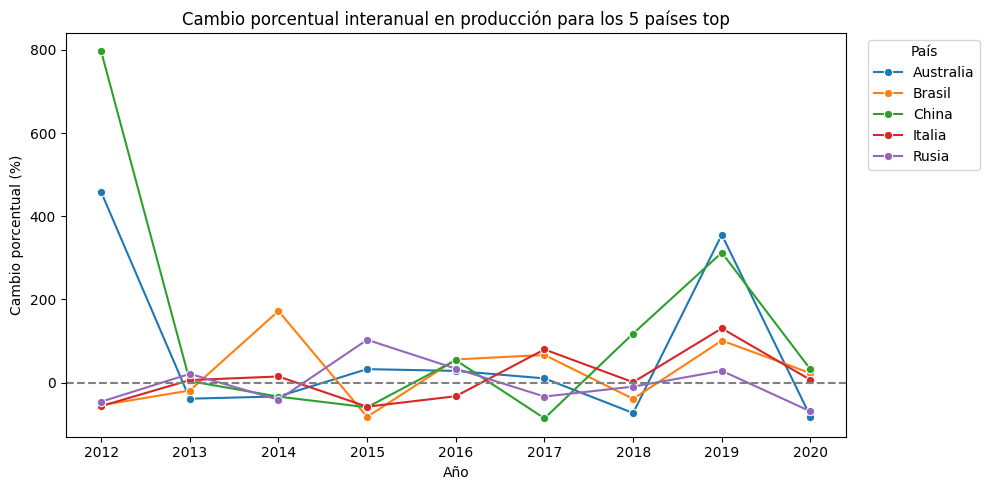

In [26]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=pais_seasonal,
    x='anio',
    y='pct_change',
    hue='pais',
    marker='o'
)
plt.title('Cambio porcentual interanual en producción para los 5 países top')
plt.xlabel('Año')
plt.ylabel('Cambio porcentual (%)')
plt.legend(title='País', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.axhline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

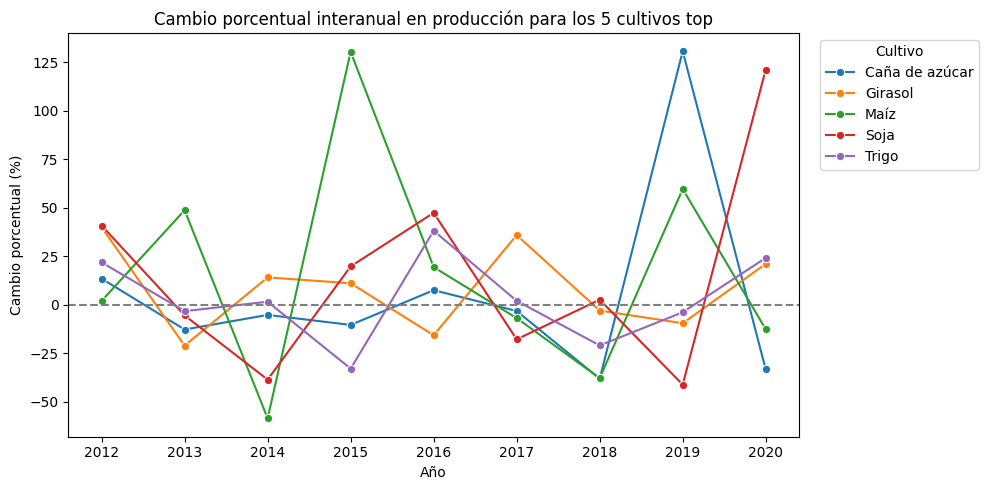

In [27]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=cultivo_seasonal,
    x='anio',
    y='pct_change',
    hue='cultivo',
    marker='o'
)
plt.title('Cambio porcentual interanual en producción para los 5 cultivos top')
plt.xlabel('Año')
plt.ylabel('Cambio porcentual (%)')
plt.legend(title='Cultivo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.axhline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

##### Interpretación:
- Los gráficos de cambio porcentual muestran si la producción sube o baja respecto al año anterior.
- La autocorrelación lag 1 indica si la producción de un año está relacionada con la del año anterior.
- Con solo datos anuales, la estacionalidad clásica (meses o ciclos cortos) no es visible; en su lugar, buscamos patrones de crecimiento/caída recurrentes.

### 3.6 Clusterización de países por patrones productivos

##### Para agrupar países según su comportamiento productivo, usamos las series temporales de producción anual y aplicamos un algoritmo de clustering. Esto nos ayuda a identificar grupos de países con patrones similares de producción.

In [28]:
pais_features = produccion_pais.pivot(index='pais', columns='anio', values='produccion_ton').fillna(0)

scaler = StandardScaler()
pais_scaled = scaler.fit_transform(pais_features)

n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
pais_clusters = kmeans.fit_predict(pais_scaled)

pais_cluster_df = pd.DataFrame({
    'pais': pais_features.index,
    'cluster': pais_clusters
}).set_index('pais')

print('Número de países por cluster:')
print(pais_cluster_df['cluster'].value_counts().sort_index())

print('\nPaíses en cada cluster:')
print(pais_cluster_df.reset_index().groupby('cluster')['pais'].apply(list))

pais_profiles = pais_features.join(pais_cluster_df)
cluster_means = pais_profiles.groupby('cluster').mean()
print('\nPerfil medio de producción por cluster:')
print(cluster_means)

Número de países por cluster:
cluster
0     3
1    10
2     2
Name: count, dtype: int64

Países en cada cluster:
cluster
0                              [Brasil, China, Italia]
1    [Alemania, Australia, España, Estados Unidos, ...
2                                  [Argentina, Canadá]
Name: pais, dtype: object

Perfil medio de producción por cluster:
                 2011          2012          2013         2014          2015  \
cluster                                                                        
0        7.884072e+08  7.255197e+08  7.173843e+08  853359458.0  2.617587e+08   
1        4.092346e+08  5.246105e+08  4.504280e+08  359300950.0  4.881016e+08   
2        8.118388e+07  6.402013e+07  7.907973e+07   44843845.5  9.287603e+07   

                 2016         2017          2018          2019         2020  
cluster                                                                      
0        3.339444e+08  304626809.0  2.640215e+08  6.727218e+08  809301043.0  
1        5.2

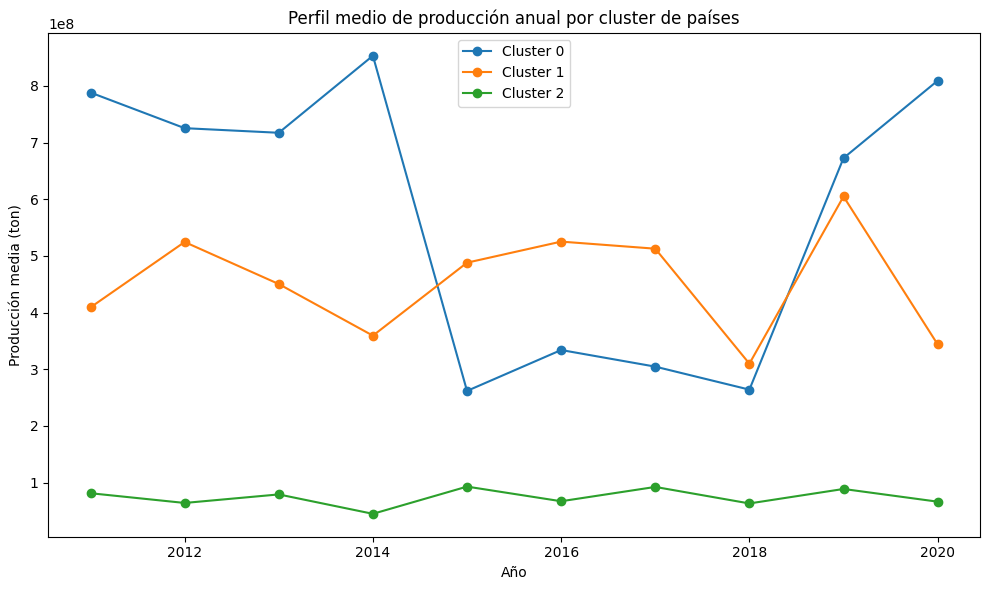

In [29]:
plt.figure(figsize=(10, 6))
for cluster_id, perfil in cluster_means.iterrows():
    plt.plot(perfil.index, perfil.values, marker='o', label=f'Cluster {cluster_id}')

plt.title('Perfil medio de producción anual por cluster de países')
plt.xlabel('Año')
plt.ylabel('Producción media (ton)')
plt.legend()
plt.tight_layout()
plt.show()

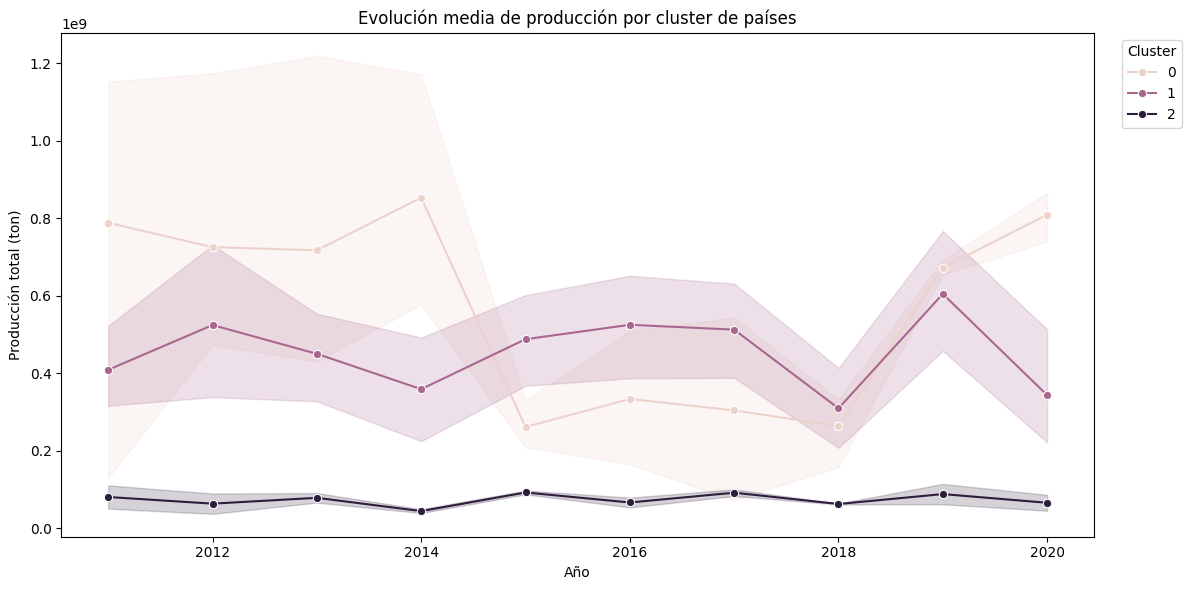

In [30]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=pais_profiles.reset_index().melt(id_vars=['pais', 'cluster'], var_name='anio', value_name='produccion_ton'),
    x='anio',
    y='produccion_ton',
    hue='cluster',
    estimator='mean',
    marker='o'
)
plt.title('Evolución media de producción por cluster de países')
plt.xlabel('Año')
plt.ylabel('Producción total (ton)')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### Interpretación:
- Cada cluster agrupa países con patrones productivos similares.
- El perfil medio de cada cluster muestra si los países del grupo tienen producción creciente, estable o más volátil.
- Para mejorar el análisis, se pueden incluir otras variables como crecimiento porcentual, volatilidad o rendimiento por hectárea.

### 3.7 Frecuencia de sequías/inundaciones por región

##### En esta sección calculamos cuántos eventos de sequía e inundación se registran por región en `condiciones_climaticas`. El dataset `politicas_agricolas` se usa como contexto de políticas por país, aunque los eventos vienen de las condiciones climáticas.

In [31]:
clima = datasets['condiciones_climaticas'].copy()
clima['evento'] = clima['regiones_eventos_extremos'].fillna('').str.strip()

# Seleccionar solo los eventos de interés: sequías e inundaciones.
evento_map = {
    'sequia_extrema': 'sequía',
    'sequia_moderada': 'sequía',
    'sequia_severa': 'sequía',
    'inundacion': 'inundación'
}
clima = clima[clima['evento'].isin(evento_map)]
clima['tipo_evento'] = clima['evento'].map(evento_map)

# Conteo total por región y tipo de evento
freq_region = (
    clima.groupby(['regiones_nombre', 'tipo_evento'])['evento']
    .count()
    .reset_index(name='conteo')
    .sort_values(['regiones_nombre', 'tipo_evento'])
)

# Conteo por región y año para ver la evolución
freq_region_year = (
    clima.groupby(['regiones_nombre', 'regiones_anio', 'tipo_evento'])['evento']
    .count()
    .reset_index(name='conteo')
)

print('Frecuencia de sequías e inundaciones por región:')
print(freq_region.pivot(index='regiones_nombre', columns='tipo_evento', values='conteo').fillna(0).sort_values('sequía', ascending=False).head(15))

Frecuencia de sequías e inundaciones por región:
tipo_evento           inundación  sequía
regiones_nombre                         
Región Principal             2.0    11.0
Ganges                       2.0     6.0
Patagonia                    0.0     4.0
Queensland Coast             2.0     4.0
Punjab                       0.0     3.0
Great Plains                 0.0     3.0
Amazonía                     0.0     3.0
Wheatbelt                    1.0     3.0
Corn Belt                    1.0     2.0
Cerrado                      0.0     2.0
Deccan                       1.0     2.0
Mata Atlántica               1.0     2.0
California                   0.0     1.0
Pampa Húmeda                 0.0     1.0
Murray-Darling Basin         1.0     0.0


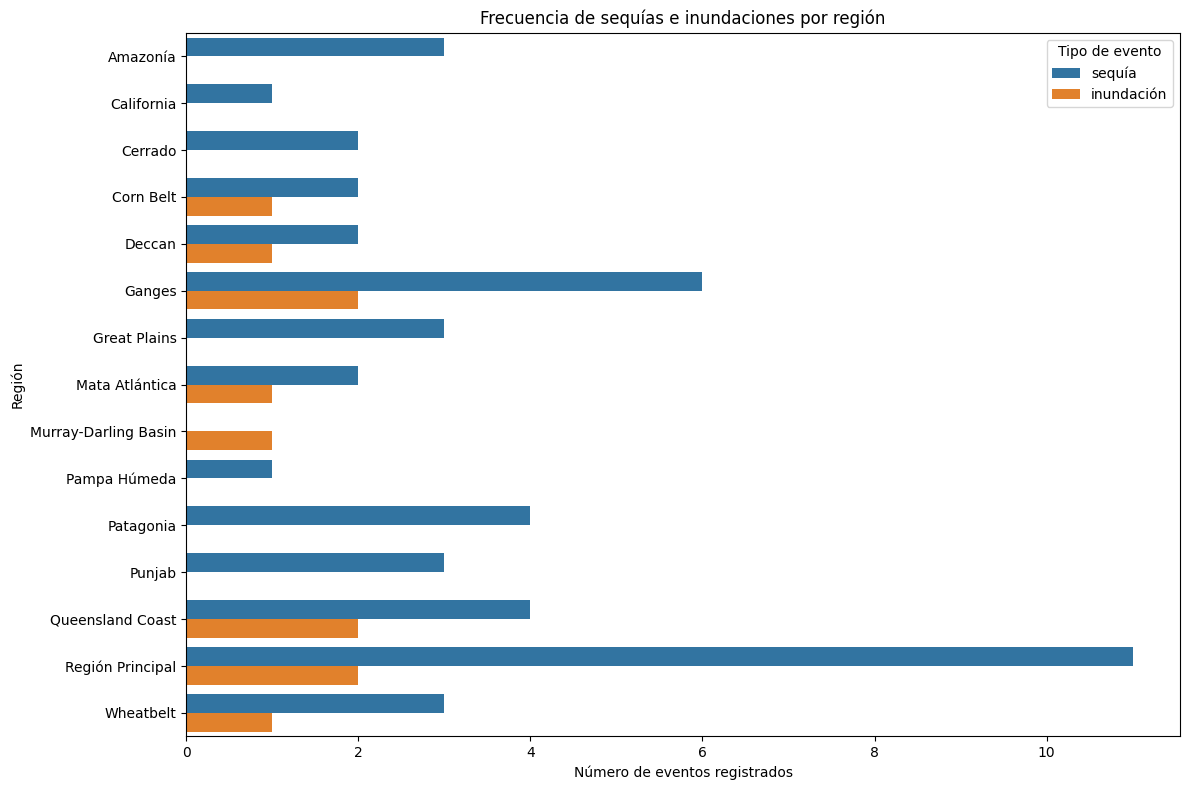

In [32]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=freq_region,
    x='conteo',
    y='regiones_nombre',
    hue='tipo_evento'
)
plt.title('Frecuencia de sequías e inundaciones por región')
plt.xlabel('Número de eventos registrados')
plt.ylabel('Región')
plt.legend(title='Tipo de evento')
plt.tight_layout()
plt.show()

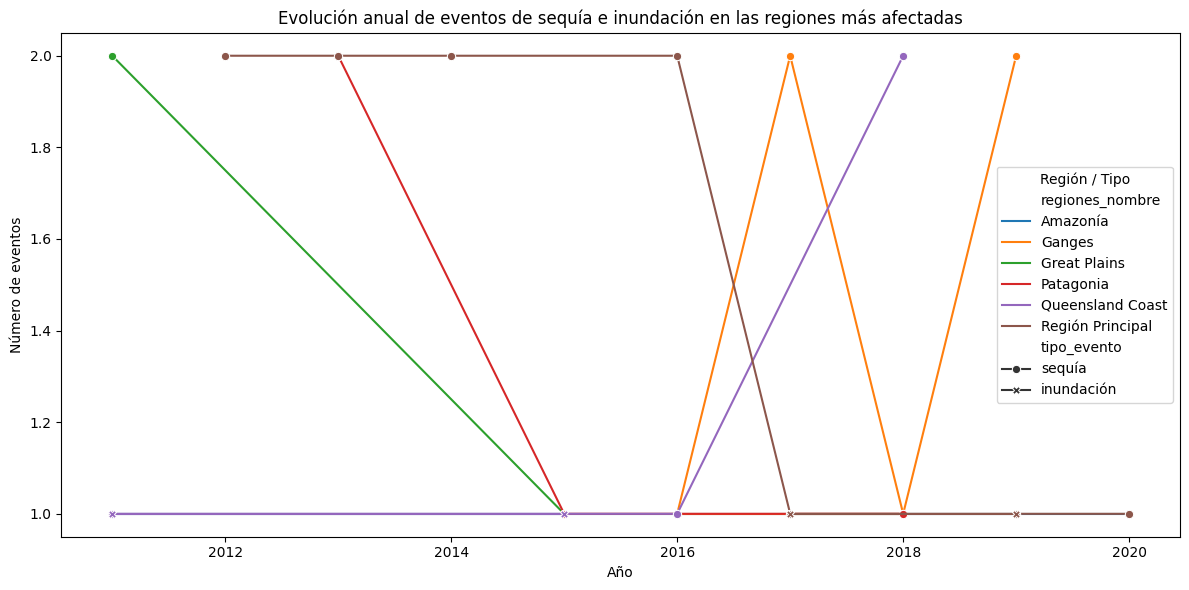

In [33]:
# Mostrar la evolución anual de los eventos en las regiones con más sequías
regiones_top = freq_region[freq_region['tipo_evento'] == 'sequía'].nlargest(6, 'conteo')['regiones_nombre'].unique()
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=freq_region_year[freq_region_year['regiones_nombre'].isin(regiones_top)],
    x='regiones_anio',
    y='conteo',
    hue='regiones_nombre',
    style='tipo_evento',
    markers=True,
    dashes=False
)
plt.title('Evolución anual de eventos de sequía e inundación en las regiones más afectadas')
plt.xlabel('Año')
plt.ylabel('Número de eventos')
plt.legend(title='Región / Tipo')
plt.tight_layout()
plt.show()

### 3.8 Impacto de políticas en producción

##### Analizamos si los países con más subsidios, regulaciones o acuerdos internacionales también muestran mayor producción agrícola.

In [34]:
pol = datasets['politicas_agricolas'].copy()
pol['subsidio_monto'] = pd.to_numeric(pol['subsidio_monto'], errors='coerce').fillna(0)
pol['subsidio_beneficiarios'] = pd.to_numeric(pol['subsidio_beneficiarios'], errors='coerce').fillna(0)
pol['acuerdo_internacional_firmado'] = pol['acuerdo_internacional_firmado'].astype(str).str.lower().map({'true': True, 'false': False})
pol['regulacion_vigente'] = pol['regulacion_vigente'].astype(str).str.lower().map({'true': True, 'false': False})

pol_group = pol.groupby('nombre').agg(
    total_subsidio=('subsidio_monto', 'sum'),
    count_subsidios=('subsidio_tipo', 'nunique'),
    total_beneficiarios=('subsidio_beneficiarios', 'sum'),
    count_regulaciones=('regulacion_tipo', 'nunique'),
    regulaciones_vigentes=('regulacion_vigente', lambda s: s.eq(True).sum()),
    acuerdos_firmados=('acuerdo_internacional_firmado', lambda s: s.eq(True).sum()),
    acuerdos_distintos=('acuerdo_internacional_nombre', 'nunique')
).reset_index()

prod_country = (
    datasets['produccion_agricola']
    .groupby('pais')['produccion_ton']
    .agg(total_produccion='sum', produccion_media_anual='mean')
    .reset_index()
)

policy_prod = prod_country.merge(pol_group, left_on='pais', right_on='nombre', how='left')

print('Países sin datos de políticas en la unión:')
print(policy_prod[policy_prod['total_subsidio'].isna()][['pais']].drop_duplicates().sort_values('pais').head(15))

policy_prod['total_subsidio'] = policy_prod['total_subsidio'].fillna(0)
policy_prod['count_regulaciones'] = policy_prod['count_regulaciones'].fillna(0)
policy_prod['regulaciones_vigentes'] = policy_prod['regulaciones_vigentes'].fillna(0)
policy_prod['acuerdos_firmados'] = policy_prod['acuerdos_firmados'].fillna(0)
policy_prod['acuerdos_distintos'] = policy_prod['acuerdos_distintos'].fillna(0)

corr_cols = [
    'total_produccion', 'produccion_media_anual',
    'total_subsidio', 'count_subsidios', 'total_beneficiarios',
    'count_regulaciones', 'regulaciones_vigentes',
    'acuerdos_firmados', 'acuerdos_distintos'
]
print('\nCorrelación entre producción y variables de políticas:')
print(policy_prod[corr_cols].corr()['total_produccion'].sort_values(ascending=False))

Países sin datos de políticas en la unión:
      pais
4   Canadá
10  Italia
14   Rusia

Correlación entre producción y variables de políticas:
total_produccion          1.000000
produccion_media_anual    1.000000
acuerdos_firmados         0.395366
total_beneficiarios       0.358657
regulaciones_vigentes     0.352049
total_subsidio            0.269694
acuerdos_distintos        0.232704
count_regulaciones        0.056551
count_subsidios          -0.429041
Name: total_produccion, dtype: float64


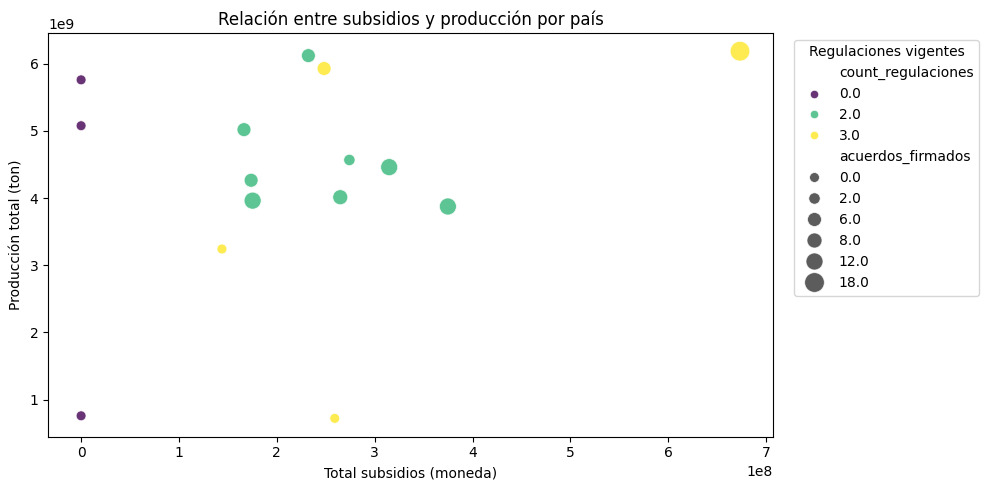

In [35]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=policy_prod,
    x='total_subsidio',
    y='total_produccion',
    hue='count_regulaciones',
    palette='viridis',
    size='acuerdos_firmados',
    sizes=(50, 200),
    alpha=0.8
)
plt.title('Relación entre subsidios y producción por país')
plt.xlabel('Total subsidios (moneda)')
plt.ylabel('Producción total (ton)')
plt.legend(title='Regulaciones vigentes', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\coast\AppData\Local\Temp\ipykernel_10612\3858594503.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


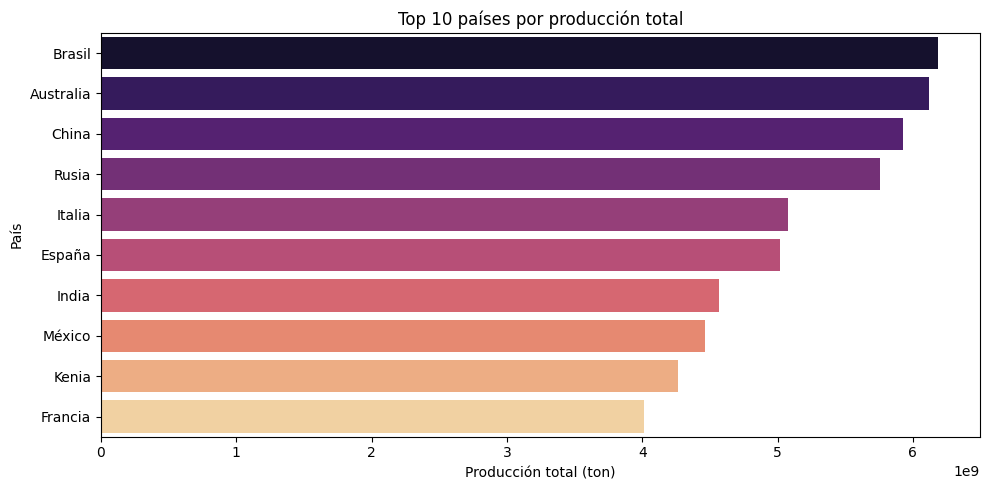

Top 10 países por inversión en subsidios:
              pais  total_subsidio  total_produccion
3           Brasil     673290900.0        6186852226
0         Alemania     374812740.0        3874736747
12          México     314838540.0        4460470748
9            India     274154396.0        4567444336
8          Francia     264844242.0        4012847594
1        Argentina     259183152.0         720411596
5            China     248318481.0        5929072220
2        Australia     232259232.0        6120959078
7   Estados Unidos     175278300.0        3961739276
11           Kenia     173744748.0        4265080819


In [36]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=policy_prod.sort_values('total_produccion', ascending=False).head(10),
    x='total_produccion',
    y='pais',
    palette='magma'
)
plt.title('Top 10 países por producción total')
plt.xlabel('Producción total (ton)')
plt.ylabel('País')
plt.tight_layout()
plt.show()

print('Top 10 países por inversión en subsidios:')
print(policy_prod.sort_values('total_subsidio', ascending=False)[['pais', 'total_subsidio', 'total_produccion']].head(10))

##### Nota: este análisis es exploratorio. La correlación entre políticas y producción no implica causalidad, y los datos de políticas son agregados por país sin un alineamiento preciso de años o montos específicos a cada producción anual.

### 3.9 Combinar políticas con datos de producción

In [37]:
# Agregamos las políticas por país y año para combinar con la producción anual
pol_year = pol.copy()
subsidios_year = (
    pol_year[pol_year['subsidio_anio'].notna()]
    .groupby(['nombre', 'subsidio_anio'])
    .agg(
        total_subsidio_anio=('subsidio_monto', 'sum'),
        count_subsidios_anio=('subsidio_tipo', 'nunique'),
        beneficiarios_anio=('subsidio_beneficiarios', 'sum')
    )
    .reset_index()
    .rename(columns={'subsidio_anio': 'anio'})
)
regulaciones_year = (
    pol_year[pol_year['regulacion_anio_implementacion'].notna()]
    .groupby(['nombre', 'regulacion_anio_implementacion'])
    .agg(
        count_regulaciones_anio=('regulacion_tipo', 'nunique'),
        regulaciones_vigentes_anio=('regulacion_vigente', lambda s: s.eq(True).sum())
    )
    .reset_index()
    .rename(columns={'regulacion_anio_implementacion': 'anio'})
)

prod_year = (
    datasets['produccion_agricola']
    .groupby(['pais', 'anio'])['produccion_ton']
    .sum()
    .reset_index()
)

combined = prod_year.merge(subsidios_year, left_on=['pais', 'anio'], right_on=['nombre', 'anio'], how='left')
combined = combined.merge(regulaciones_year, left_on=['pais', 'anio'], right_on=['nombre', 'anio'], how='left', suffixes=('_subsidio', '_regulacion'))

combined = combined.drop(columns=['nombre_subsidio', 'nombre_regulacion'], errors='ignore')
combined[['total_subsidio_anio', 'count_subsidios_anio', 'beneficiarios_anio', 'count_regulaciones_anio', 'regulaciones_vigentes_anio']] = combined[[
    'total_subsidio_anio', 'count_subsidios_anio', 'beneficiarios_anio', 'count_regulaciones_anio', 'regulaciones_vigentes_anio'
]].fillna(0)

print('Combinación de producción y políticas por país/año (muestra):')
print(combined.head())

print('\nCorrelaciones entre producción anual y políticas por año:')
print(combined[['produccion_ton', 'total_subsidio_anio', 'count_subsidios_anio', 'beneficiarios_anio', 'count_regulaciones_anio', 'regulaciones_vigentes_anio']].corr()['produccion_ton'].sort_values(ascending=False))

Combinación de producción y políticas por país/año (muestra):
       pais  anio  produccion_ton  total_subsidio_anio  count_subsidios_anio  \
0  Alemania  2011       442481570                  0.0                   0.0   
1  Alemania  2012       350211883                  0.0                   0.0   
2  Alemania  2013       166339315                  0.0                   0.0   
3  Alemania  2014       358812958                  0.0                   0.0   
4  Alemania  2015       420178305                  0.0                   0.0   

   beneficiarios_anio  count_regulaciones_anio  regulaciones_vigentes_anio  
0                 0.0                      0.0                         0.0  
1                 0.0                      0.0                         0.0  
2                 0.0                      0.0                         0.0  
3                 0.0                      0.0                         0.0  
4                 0.0                      1.0                         0

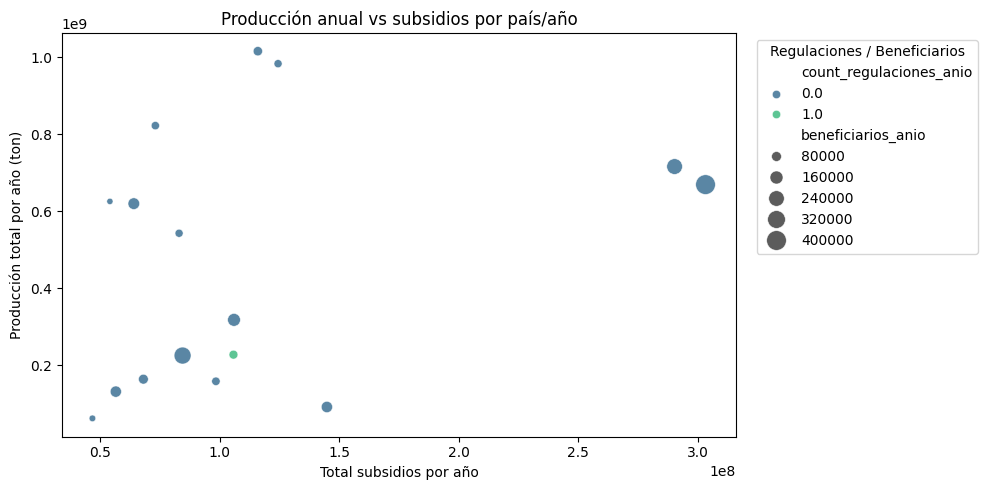

In [38]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=combined[combined['total_subsidio_anio'] > 0],
    x='total_subsidio_anio',
    y='produccion_ton',
    hue='count_regulaciones_anio',
    size='beneficiarios_anio',
    sizes=(20, 200),
    palette='viridis',
    alpha=0.8
)
plt.title('Producción anual vs subsidios por país/año')
plt.xlabel('Total subsidios por año')
plt.ylabel('Producción total por año (ton)')
plt.legend(title='Regulaciones / Beneficiarios', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### Este bloque combina la política pública con la producción anual. Aunque los datos no están perfectamente alineados, permite ver si los años con más subsidios o más regulaciones coinciden con mayor producción.

### 3.10 Relacionar subsidios con incrementos de rendimiento

##### Aquí relacionamos el cambio interanual del rendimiento (`rendimiento_ton_ha`) con los subsidios asignados por país y año.

In [39]:
yield_year = (
    datasets['produccion_agricola']
    .groupby(['pais', 'anio'])['rendimiento_ton_ha']
    .mean()
    .reset_index()
    .sort_values(['pais', 'anio'])
)
yield_year['delta_rendimiento'] = yield_year.groupby('pais')['rendimiento_ton_ha'].diff()
yield_year['pct_change_rendimiento'] = yield_year.groupby('pais')['rendimiento_ton_ha'].pct_change() * 100

yield_subsidio = yield_year.merge(
    subsidios_year,
    left_on=['pais', 'anio'],
    right_on=['nombre', 'anio'],
    how='left'
).drop(columns=['nombre'], errors='ignore')

yield_subsidio[['total_subsidio_anio', 'count_subsidios_anio', 'beneficiarios_anio']] = yield_subsidio[[
    'total_subsidio_anio', 'count_subsidios_anio', 'beneficiarios_anio'
]].fillna(0)

print('Muestra de rendimiento combinado con subsidios:')
print(yield_subsidio.head())

print('\nCorrelación entre delta de rendimiento y subsidios:')
print(yield_subsidio[
    ['delta_rendimiento', 'pct_change_rendimiento', 'total_subsidio_anio', 'count_subsidios_anio', 'beneficiarios_anio']
].corr()['delta_rendimiento'].sort_values(ascending=False))

Muestra de rendimiento combinado con subsidios:
       pais  anio  rendimiento_ton_ha  delta_rendimiento  \
0  Alemania  2011            12.56625                NaN   
1  Alemania  2012            16.39375            3.82750   
2  Alemania  2013            12.25875           -4.13500   
3  Alemania  2014            18.96750            6.70875   
4  Alemania  2015            14.88250           -4.08500   

   pct_change_rendimiento  total_subsidio_anio  count_subsidios_anio  \
0                     NaN                  0.0                   0.0   
1               30.458570                  0.0                   0.0   
2              -25.223027                  0.0                   0.0   
3               54.726216                  0.0                   0.0   
4              -21.536839                  0.0                   0.0   

   beneficiarios_anio  
0                 0.0  
1                 0.0  
2                 0.0  
3                 0.0  
4                 0.0  

Correlación e

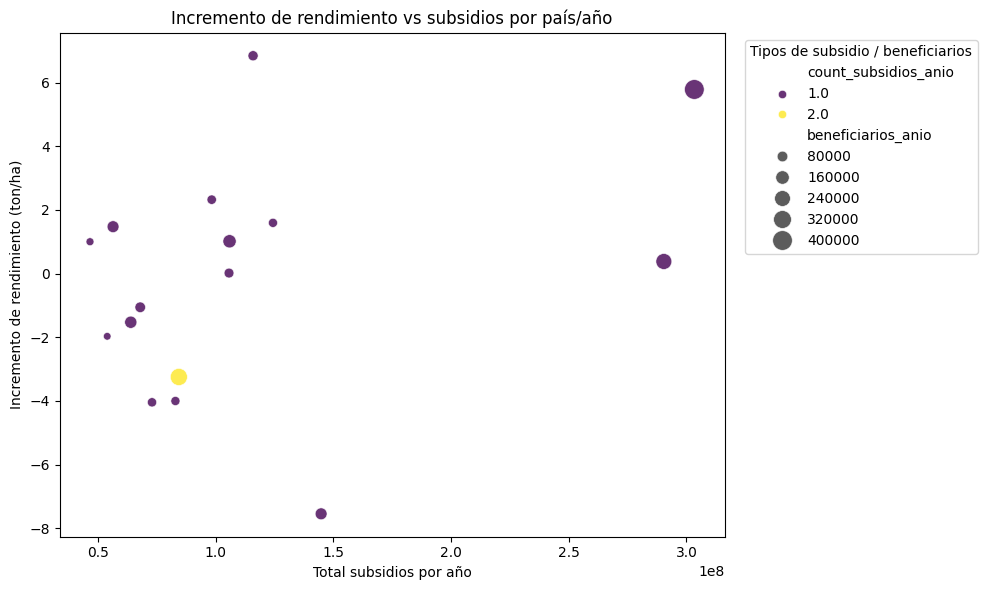

In [40]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=yield_subsidio[yield_subsidio['delta_rendimiento'].notna() & (yield_subsidio['total_subsidio_anio'] > 0)],
    x='total_subsidio_anio',
    y='delta_rendimiento',
    hue='count_subsidios_anio',
    size='beneficiarios_anio',
    sizes=(30, 200),
    palette='viridis',
    alpha=0.8
)
plt.title('Incremento de rendimiento vs subsidios por país/año')
plt.xlabel('Total subsidios por año')
plt.ylabel('Incremento de rendimiento (ton/ha)')
plt.legend(title='Tipos de subsidio / beneficiarios', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

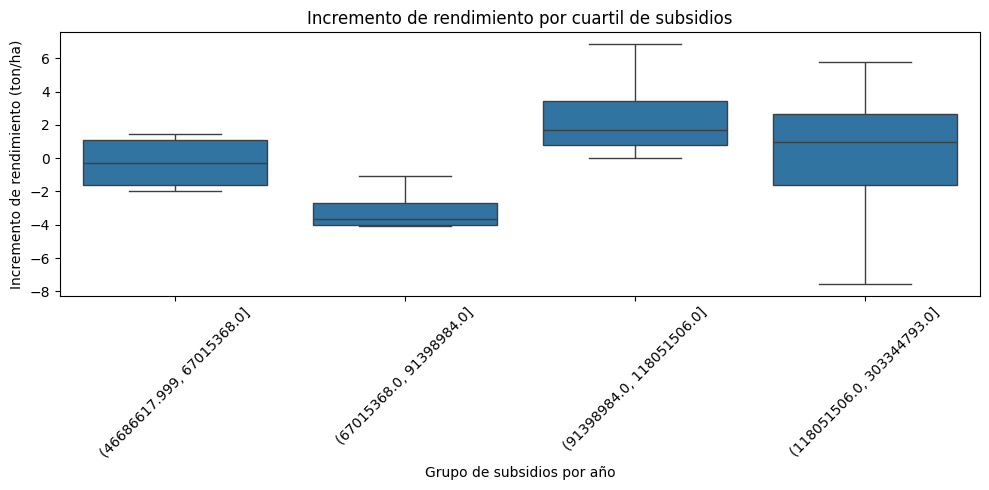

In [41]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=yield_subsidio[yield_subsidio['total_subsidio_anio'] > 0],
    x=pd.qcut(yield_subsidio[yield_subsidio['total_subsidio_anio'] > 0]['total_subsidio_anio'], q=4, duplicates='drop'),
    y='delta_rendimiento'
)
plt.xticks(rotation=45)
plt.title('Incremento de rendimiento por cuartil de subsidios')
plt.xlabel('Grupo de subsidios por año')
plt.ylabel('Incremento de rendimiento (ton/ha)')
plt.tight_layout()
plt.show()

##### Esta comparación muestra si los años con más subsidios tienden a presentar mayores incrementos del rendimiento agrícola. El análisis sigue siendo exploratorio y es conveniente usarlo como una guía inicial, no como una prueba causal definitiva.

### 3.11 Extracción de entidades: plagas, cultivos, países, fechas

##### Extraemos entidades clave de los textos y de los campos estructurados en `noticias_agricolas` y `reportes_plagas`.

### 3.11 Extracción de entidades: plagas, cultivos, países, fechas

##### Extraemos entidades clave de los textos y de los campos estructurados en `noticias_agricolas` y `reportes_plagas`.

In [42]:
import re

noticias = datasets['noticias_agricolas'].copy()
reportes = datasets['reportes_plagas'].copy()

# Normalizar fechas en los dos datasets
noticias['fecha'] = pd.to_datetime(noticias['fecha'], errors='coerce')
reportes['Fecha'] = pd.to_datetime(reportes['Fecha'], dayfirst=True, errors='coerce')

# Entidades desde campos estructurados
plagas_reportadas = reportes['Plaga/Enfermedad detectada'].dropna().unique()
cultivos_reportados = reportes['Cultivo'].dropna().unique()
paises_reportes = reportes['Pais'].dropna().unique()

paises_noticias = (
    noticias['paises_afectados']
    .dropna()
    .str.split('\|')
    .explode()
    .str.strip()
    .unique()
)
cultivos_noticias = noticias['impacto_cultivos'].dropna().unique()

print('Plagas reportadas (reportes_plagas):', plagas_reportadas)
print('Cultivos reportados (reportes_plagas):', cultivos_reportados)
print('Países en reportes de plagas:', paises_reportes[:20])
print('Países en noticias agrícolas:', paises_noticias[:20])
print('Cultivos en noticias agrícolas:', cultivos_noticias[:20])

Plagas reportadas (reportes_plagas): <StringArray>
[    'Gusano cogollero',                'Ácaro', 'Barrenador del tallo',
          'Piricularia',             'Langosta',      'Roya de la hoja',
               'Pulgón',             'Fusarium',               'Mildiu',
          'Podredumbre', 'Oruga militar tardía',         'Mosca blanca',
       'Chinche marrón',         'Tizón tardío',                'Oídio',
        'Roya amarilla',          'Antracnosis']
Length: 17, dtype: str
Cultivos reportados (reportes_plagas): <StringArray>
[         'Arroz',           'Soja',        'Girasol',        'Algodón',
         'Cebada',           'Maíz',          'Trigo', 'Caña de azúcar',
             'Té',           'Café']
Length: 10, dtype: str
Países en reportes de plagas: <StringArray>
[     'Australia', 'Estados Unidos',        'Francia',          'China',
         'Brasil',       'Alemania',          'India',      'Argentina']
Length: 8, dtype: str
Países en noticias agrícolas: <StringArra

<>:18: SyntaxWarning: invalid escape sequence '\|'
<>:18: SyntaxWarning: invalid escape sequence '\|'
C:\Users\coast\AppData\Local\Temp\ipykernel_10612\433737633.py:18: SyntaxWarning: invalid escape sequence '\|'
  .str.split('\|')


In [43]:
# Detectar entidades en texto usando listas conocidas
known_plagas = [str(x).lower() for x in plagas_reportadas if pd.notna(x)]
known_cultivos = [str(x).lower() for x in pd.concat([pd.Series(cultivos_reportados), pd.Series(cultivos_noticias)]).dropna().unique()]
known_paises = [str(x).lower() for x in pd.concat([pd.Series(paises_reportes), pd.Series(paises_noticias)]).dropna().unique()]

# Función simple de marcado con listas conocidas

def extract_keywords(text, keywords):
    if pd.isna(text):
        return []
    text_lower = text.lower()
    return sorted({k for k in keywords if k in text_lower})

noticias['plagas_en_texto'] = noticias['contenido'].apply(lambda t: extract_keywords(t, known_plagas))
noticias['cultivos_en_texto'] = noticias['contenido'].apply(lambda t: extract_keywords(t, known_cultivos))
noticias['paises_en_texto'] = noticias['contenido'].apply(lambda t: extract_keywords(t, known_paises))

# Extraer fechas en texto
date_pattern = r'\b\d{4}-\d{2}-\d{2}\b|\b\d{2}/\d{2}/\d{4}\b|\b\d{2}-\d{2}-\d{4}\b'
noticias['fechas_en_texto'] = noticias['contenido'].astype(str).str.findall(date_pattern)

print('Ejemplo de extracción en noticias:')
print(noticias[['titular', 'paises_en_texto', 'cultivos_en_texto', 'plagas_en_texto', 'fechas_en_texto']].head(5).to_string(index=False))

Ejemplo de extracción en noticias:
                                                          titular paises_en_texto cultivos_en_texto plagas_en_texto fechas_en_texto
   Nueva política agrícola en Canadá busca mejorar sostenibilidad        [canadá]                []              []              []
                        Ola de calor reduce rendimientos de Arroz        [canadá]           [arroz]              []              []
                Sequía afecta proyecciones de cosecha en Alemania      [alemania]            [maíz]              []              []
Nueva política agrícola en Argentina busca mejorar sostenibilidad     [argentina]                []              []              []
                    Demanda china impulsa mercado de carne_bovina         [rusia]    [carne_bovina]              []              []


In [44]:
# Extraer entidades del dataset de reportes de plagas
reportes['plagas_extraidas'] = reportes['Plaga/Enfermedad detectada'].astype(str)
reportes['cultivos_extraidos'] = reportes['Cultivo'].astype(str)
reportes['paises_extraidos'] = reportes['Pais'].astype(str)
reportes['fecha_extraida'] = reportes['Fecha']

print('\nConteo de entidades extraídas de reportes de plagas:')
print('Plagas:', reportes['plagas_extraidas'].nunique())
print('Cultivos:', reportes['cultivos_extraidos'].nunique())
print('Países:', reportes['paises_extraidos'].nunique())
print('Fechas válidas:', reportes['fecha_extraida'].notna().sum())


Conteo de entidades extraídas de reportes de plagas:
Plagas: 17
Cultivos: 10
Países: 8
Fechas válidas: 100


##### Con esto ya tienes una extracción básica de las entidades principales. Si quieres, podemos refinarla con NLP más avanzado, detección de nombres propios o reconocimiento de fechas en textos no estructurados.

### 3.12 Análisis de sentimiento en noticias

##### Realizamos un análisis de sentimiento simple en los textos de `noticias_agricolas` usando un enfoque lexicográfico con palabras positivas y negativas.

In [45]:
import re

noticias_texto = datasets['noticias_agricolas'].copy()
noticias_texto['contenido'] = noticias_texto['contenido'].astype(str)

positive_words = {
    'positivo', 'mejor', 'mejora', 'crecimiento', 'aumento', 'favorable',
    'beneficio', 'beneficios', 'excelente', 'sostenible', 'apoya', 'apoyo',
    'recuperación', 'recuperacion', 'estable', 'optimista', 'oportunidad',
    'avance', 'avances', 'superior', 'supera', 'superan'
}
negative_words = {
    'pérdida', 'perdida', 'baja', 'caída', 'caida', 'reducción', 'reduccion',
    'disminución', 'disminucion', 'grave', 'crítico', 'critico', 'malo',
    'malos', 'peligro', 'riesgo', 'problema', 'problemas', 'sequía', 'sequia',
    'inundación', 'inundacion', 'daño', 'dano', 'descenso', 'peor', 'caos',
    'alerta', 'extremo', 'extremos', 'crisis', 'dañino', 'danino', 'amenaza'
}

word_pattern = re.compile(r"\b[\wáéíóúñÁÉÍÓÚÑ]+\b", flags=re.IGNORECASE)

def sentiment_scores(text: str) -> tuple[int, int, int]:
    words = word_pattern.findall(text.lower())
    pos = sum(1 for w in words if w in positive_words)
    neg = sum(1 for w in words if w in negative_words)
    return pos, neg, pos - neg

noticias_texto[['pos_count', 'neg_count', 'sentiment_score']] = noticias_texto['contenido'].apply(
    lambda t: pd.Series(sentiment_scores(t))
)

noticias_texto['sentimiento'] = noticias_texto['sentiment_score'].apply(
    lambda s: 'positivo' if s > 0 else ('negativo' if s < 0 else 'neutral')
)

print('Distribución de sentimiento en noticias:')
print(noticias_texto['sentimiento'].value_counts())

Distribución de sentimiento en noticias:
sentimiento
neutral     49
negativo    11
Name: count, dtype: int64


C:\Users\coast\AppData\Local\Temp\ipykernel_10612\1138178470.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=noticias_texto, x='sentimiento', order=['positivo', 'neutral', 'negativo'], palette=['green', 'gray', 'red'])


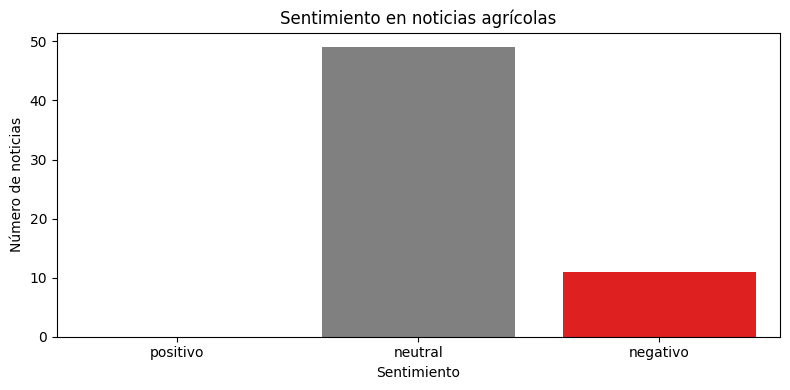

In [46]:
plt.figure(figsize=(8, 4))
sns.countplot(data=noticias_texto, x='sentimiento', order=['positivo', 'neutral', 'negativo'], palette=['green', 'gray', 'red'])
plt.title('Sentimiento en noticias agrícolas')
plt.xlabel('Sentimiento')
plt.ylabel('Número de noticias')
plt.tight_layout()
plt.show()

In [47]:
print('Titulares más positivos:')
print(noticias_texto[noticias_texto['sentimiento'] == 'positivo'][['titular', 'sentiment_score']].head(5).to_string(index=False))
print('\nTitulares más negativos:')
print(noticias_texto[noticias_texto['sentimiento'] == 'negativo'][['titular', 'sentiment_score']].head(5).to_string(index=False))

Titulares más positivos:
Empty DataFrame
Columns: [titular, sentiment_score]
Index: []

Titulares más negativos:
                                                titular  sentiment_score
              Ola de calor reduce rendimientos de Arroz               -1
      Sequía afecta proyecciones de cosecha en Alemania               -1
Sequía afecta proyecciones de cosecha en Estados Unidos               -1
         Sequía afecta proyecciones de cosecha en Kenia               -1
         Sequía afecta proyecciones de cosecha en Kenia               -1


In [48]:
if 'categoria' in noticias_texto.columns:
    print('\nSentimiento por categoría:')
    print(noticias_texto.groupby('categoria')['sentimiento'].value_counts(normalize=True).unstack(fill_value=0).round(2))


Sentimiento por categoría:
sentimiento  neutral  negativo
categoria                     
clima            0.0       1.0
comercio         1.0       0.0
mercado          1.0       0.0
politica         1.0       0.0
sanidad          1.0       0.0
tecnologia       1.0       0.0


##### Este es un análisis de sentimiento básico orientado a identificar si los titulares y contenidos de las noticias tienen tono positivo, negativo o neutro. Si necesitas un modelo más preciso, podemos integrar un paquete externo como `textblob` o `nltk` cuando esté disponible.

### 3.12 Topic modeling de reportes de plagas
##### Aplicamos una descomposición LDA sobre el texto de los reportes de plagas para identificar temas recurrentes en los tratamientos y plagas detectadas.

In [ ]:
reportes = datasets['reportes_plagas'].copy()
reportes['Fecha'] = pd.to_datetime(reportes['Fecha'], dayfirst=True, errors='coerce')

# Construir un texto de documento por reporte
reportes['documento'] = (
    reportes['Cultivo'].astype(str) + ' ' +
    reportes['Plaga/Enfermedad detectada'].astype(str) + ' ' +
    reportes['Tratamiento aplicado'].astype(str) + ' ' +
    reportes['Region'].astype(str) + ' ' +
    reportes['Pais'].astype(str)
)

vectorizer = CountVectorizer(
    stop_words='spanish',
    max_df=0.85,
    min_df=2,
    ngram_range=(1, 2)
)
X = vectorizer.fit_transform(reportes['documento'].fillna(''))

n_topics = 5
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit(X)

feature_names = vectorizer.get_feature_names_out()
def get_top_words(model, feature_names, n_top_words):
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_features = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        topics.append(' '.join(top_features))
    return topics

topics = get_top_words(lda, feature_names, 10)
for i, topic in enumerate(topics):
    print(f'Tema {i+1}: {topic}')

In [ ]:
# Asignar el tema dominante a cada reporte
reportes['topic'] = lda.transform(X).argmax(axis=1)

print('\nEjemplo de reportes con tema dominante:')
print(reportes[['Fecha', 'Region', 'Pais', 'Cultivo', 'Plaga/Enfermedad detectada', 'Tratamiento aplicado', 'topic']].head(10).to_string(index=False))

print('\nNúmero de reportes por tema:')
print(reportes['topic'].value_counts().sort_index())

##### Con este topic modeling puedes ver qué temas emergen en los reportes de plagas y cómo se distribuyen entre cultivos y regiones. Si quieres, podemos ajustar el número de temas o el vectorizador para obtener tópicos más específicos.